# Cosine Similarity with Heatmap Visualization

This notebook demonstrates:
- Generating synthetic document vectors (embeddings)
- Calculating cosine similarity between documents
- Visualizing the similarity matrix as a heatmap

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Set random seed for reproducibility
np.random.seed(42)

## Generate Synthetic Data

Create synthetic document embeddings (vectors representing documents in a high-dimensional space)

In [3]:
# Generate synthetic document embeddings
n_documents = 8  # Number of documents
n_features = 50   # Dimensionality of embeddings

# Create random document vectors (normalized)
document_vectors = np.random.randn(n_documents, n_features)

# Normalize vectors (optional, but common for embeddings)
document_vectors = document_vectors / np.linalg.norm(document_vectors, axis=1, keepdims=True)
print(document_vectors[1])
# Create document labels
document_labels = [f"Doc {i+1}" for i in range(n_documents)]

print(f"Generated {n_documents} document vectors with {n_features} features")
print(f"Shape: {document_vectors.shape}")

[ 0.05294135 -0.06290584 -0.11057987  0.09992153  0.16842087  0.15213102
 -0.13709196 -0.05051197  0.05411416  0.15936201 -0.07827641 -0.03032867
 -0.18072744 -0.19540859  0.13273169  0.22155115 -0.01176335  0.16393401
  0.05907574 -0.10538475  0.05903646  0.25124887 -0.00585243  0.25559532
 -0.4279534   0.13426343  0.01421974 -0.04884491  0.01498975 -0.32468307
 -0.03588492  0.0583368   0.24142417 -0.08466301 -0.132073   -0.08196547
  0.14953724  0.05370376 -0.08653998  0.08384577  0.01585829  0.15823483
 -0.11468521 -0.05352587 -0.06405357 -0.23907525  0.04837329  0.04264518
  0.00083532 -0.03832142]
Generated 8 document vectors with 50 features
Shape: (8, 50)


## Calculate Cosine Similarity

Compute pairwise cosine similarity between all documents

In [4]:
# Calculate cosine similarity matrix
similarity_matrix = cosine_similarity(document_vectors)

print("Cosine Similarity Matrix:")
print(similarity_matrix)
print(f"\nMatrix shape: {similarity_matrix.shape}")

Cosine Similarity Matrix:
[[ 1.          0.10204581 -0.11266292  0.08101267  0.28744461  0.22484709
  -0.20972148 -0.32011933]
 [ 0.10204581  1.         -0.2316379  -0.16994661 -0.15488025  0.06490562
  -0.0056848  -0.16294966]
 [-0.11266292 -0.2316379   1.          0.05020463  0.16573061 -0.00753546
  -0.01383806  0.10864182]
 [ 0.08101267 -0.16994661  0.05020463  1.         -0.0134933  -0.26718218
   0.21771803 -0.01585127]
 [ 0.28744461 -0.15488025  0.16573061 -0.0134933   1.          0.29437943
  -0.00630265 -0.11798089]
 [ 0.22484709  0.06490562 -0.00753546 -0.26718218  0.29437943  1.
   0.01656099  0.01758111]
 [-0.20972148 -0.0056848  -0.01383806  0.21771803 -0.00630265  0.01656099
   1.          0.10162952]
 [-0.32011933 -0.16294966  0.10864182 -0.01585127 -0.11798089  0.01758111
   0.10162952  1.        ]]

Matrix shape: (8, 8)


## Visualize with Heatmap

Create a heatmap to visualize the similarity matrix

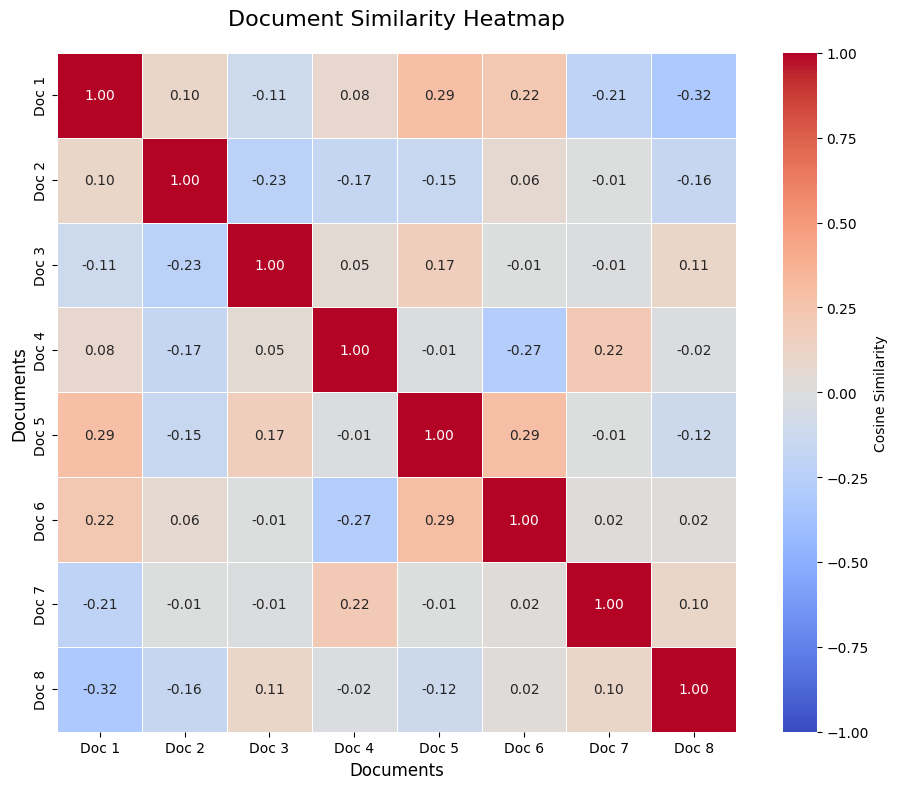

In [5]:
# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, 
            annot=True,  # Show values in cells
            fmt='.2f',   # Format numbers to 2 decimal places
            cmap='coolwarm',  # Color scheme
            xticklabels=document_labels,
            yticklabels=document_labels,
            vmin=-1, vmax=1,  # Cosine similarity ranges from -1 to 1
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Cosine Similarity'})

plt.title('Document Similarity Heatmap', fontsize=16, pad=20)
plt.xlabel('Documents', fontsize=12)
plt.ylabel('Documents', fontsize=12)
plt.tight_layout()
plt.show()